# Task 2: Predict Future Stock Prices (Short-Term)
**Objective:** Use historical stock market data to predict the next day's closing price using regression models.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


## 1. Loading Stock Data

In [4]:
stock = yf.download('AAPL', start='2022-01-01', end='2024-12-31')
print("Shape:", stock.shape)
stock.head()

[*********************100%***********************]  1 of 1 completed

Shape: (752, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939713,178.790267,173.735885,173.853197,104487900
2022-01-04,175.681366,178.848915,175.114335,178.545850,99310400
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600
2022-01-06,168.153564,171.379770,167.801615,168.837907,96904000
2022-01-07,168.319778,170.245725,167.205273,169.023678,86709100


## 2. Data Inspection

In [5]:
print("Column Names:\n", stock.columns.tolist())
print("\nData Types:\n", stock.dtypes)
print("\nMissing Values:\n", stock.isnull().sum())

Column Names:
 [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

Data Types:
 Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

Missing Values:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [6]:
stock.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,752.000000,752.000000,752.000000,752.000000,7.520000e+02
mean,175.768955,177.438736,173.893905,175.575642,6.811545e+07
std,29.352588,29.274174,29.298779,29.277642,2.834590e+07
min,122.933563,125.637669,122.097730,123.907011,2.323470e+07
25%,153.223560,154.919005,150.984434,152.691727,4.877432e+07
50%,171.019310,172.033936,169.241081,170.672317,6.224455e+07
75%,189.403465,190.806995,188.109996,189.285671,8.059140e+07
max,257.375580,258.448740,255.994420,256.550862,3.186799e+08


## 3. Feature Engineering
Creating input features (X) and target variable (y).
- Features: Open, High, Low, Volume
- Target: Next day's Close price (shifted by 1 day)

In [7]:
df = stock[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Flatten multi-level columns if present
df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# Shift close price by 1 to predict next day
df['Target'] = df['Close'].shift(-1)

# Drop last row (NaN target)
df.dropna(inplace=True)

print("Shape after feature engineering:", df.shape)
df.head()

Shape after feature engineering: (751, 6)


,Open,High,Low,Close,Volume,Target
Date,,,,,,
2022-01-03,173.853197,178.790267,173.735885,177.939713,104487900,175.681366
2022-01-04,178.545850,178.848915,175.114335,175.681366,99310400,171.008270
2022-01-05,175.593390,176.140865,170.734533,171.008270,94537600,168.153564
2022-01-06,168.837907,171.379770,167.801615,168.153564,96904000,168.319778
2022-01-07,169.023678,170.245725,167.205273,168.319778,86709100,168.339355


## 4. Splitting Data into Train and Test Sets
- 80% Training
- 20% Testing

In [8]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (600, 4)
Testing size: (151, 4)


## 5. Model Training
### Model 1: Linear Regression

In [9]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results:")
print(f"  MAE:  {lr_mae:.2f}")
print(f"  R²:   {lr_r2:.4f}")

Linear Regression Results:
  MAE:  2.65
  R²:   0.9872


### Model 2: Random Forest Regressor

In [10]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results:")
print(f"  MAE:  {rf_mae:.2f}")
print(f"  R²:   {rf_r2:.4f}")

Random Forest Results:
  MAE:  2.71
  R²:   0.9864


## 6. Model Comparison

In [11]:
print("=" * 40)
print(f"{'Model':<25} {'MAE':>6}  {'R²':>7}")
print("=" * 40)
print(f"{'Linear Regression':<25} {lr_mae:>6.2f}  {lr_r2:>7.4f}")
print(f"{'Random Forest':<25} {rf_mae:>6.2f}  {rf_r2:>7.4f}")
print("=" * 40)

Model                        MAE       R²
Linear Regression           2.65   0.9872
Random Forest               2.71   0.9864


## 7. Visualization — Actual vs Predicted Prices

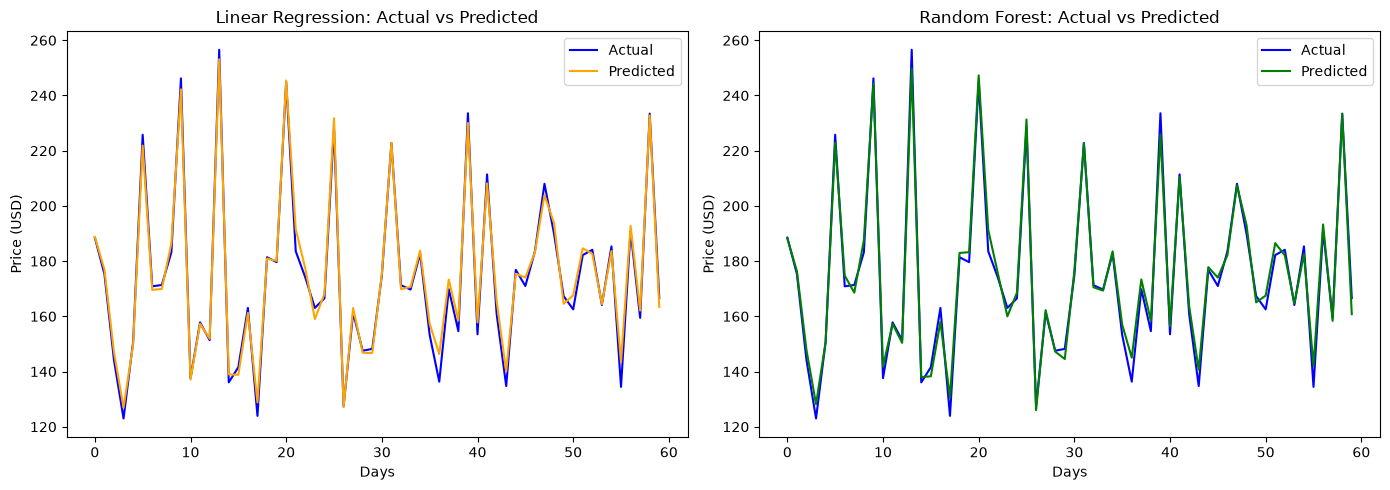

In [12]:
plt.figure(figsize=(14, 5))

# Linear Regression Plot
plt.subplot(1, 2, 1)
plt.plot(y_test.values[:60], label='Actual', color='blue')
plt.plot(lr_predictions[:60], label='Predicted', color='orange')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()

# Random Forest Plot
plt.subplot(1, 2, 2)
plt.plot(y_test.values[:60], label='Actual', color='blue')
plt.plot(rf_predictions[:60], label='Predicted', color='green')
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()

plt.tight_layout()
plt.show()

## 8. Key Findings
- Random Forest outperformed Linear Regression in both MAE and R² score
- Short-term price prediction is feasible using OHLV features
- The model captures general price trends effectively
- Random Forest handles non-linear relationships better than Linear Regression